[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T05_D_lp_did_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "notebooks", Path.cwd() / "curso/notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

# DiD se encuentra con las proyecciones locales: LP-DiD

Cuando una política macroeconómica se despliega por estados o regiones en sucesivas oleadas, sus efectos rara vez se materializan de forma instantánea; se acumulan dinámicamente con el tiempo. La macroeconomía aplicada requiere la función de respuesta al impulso completa a lo largo de los horizontes —no un único escalar contaminado. El módulo anterior (`T05_C_staggered_did_es`) demostró por qué la regresión con efectos fijos en dos vías (TWFE) de libro de texto colapsa ante la heterogeneidad de efectos dinámicos y cómo Callaway & Sant'Anna (2021) resuelven la crisis.

Este módulo presenta la solución desde las *proyecciones locales*: **LP-DiD** (Dube, Girardi, Jordà & Taylor 2023). LP-DiD conserva la arquitectura flexible y familiar de regresión horizonte a horizonte de Jordà (2005), pero impone una regla muestral estricta: cada comparación se restringe estrictamente a unidades recién tratadas frente a controles *limpios* (unidades que permanecen sin tratar hasta el horizonte de proyección). Demostramos cómo los estudios de eventos dinámicos ingenuos de TWFE fabrican tendencias previas espurias y sesgan a la baja el efecto de impacto, recuperamos la trayectoria dinámica verdadera con `puremacro.lp.lp_did`, confirmamos que Callaway-Sant'Anna, Sun-Abraham y LP-DiD convergen a la misma senda causal, y ejecutamos diagnósticos de ponderación empíricos sobre paneles laborales estatales (`data_curso/paro_estatal_mensual.csv`).

## El método en ecuaciones

**Planteamiento.** La unidad $i$ adopta una política de tratamiento absorbente en la fecha $G_i \in \{g_1, \dots, g_K\} \cup \{\infty\}$ (con $\infty$ para los controles nunca tratados). Sea $D_{it} = \mathbb{1}\{t \ge G_i\}$ y $\Delta D_{it} = 1$ el indicador del período de cambio o adopción. Los resultados potenciales incorporan dinámicas específicas por cohorte y efectos de tratamiento variantes en el tiempo $\tau_{it}(g, t)$.

**El fallo del estudio de eventos TWFE saturado.** Con frecuencia se estiman estudios de eventos dinámicos mediante TWFE:
$$ Y_{it} = \alpha_i + \lambda_t + \sum_{e=-K, e \ne -1}^L \beta_e \mathbb{1}\{t - G_i = e\} + \varepsilon_{it} $$
Bajo adopción escalonada con heterogeneidad dinámica, el teorema de contaminación de Sun & Abraham (2021) demuestra que cada coeficiente estimado $\hat{\beta}_e$ es una combinación ponderada de efectos reales en *otros* tiempos relativos y de *otras* cohortes. Por consiguiente, los efectos posteriores al tratamiento contaminan los adelantos previos, provocando rechazos espurios de tendencias paralelas incluso cuando estas se cumplen por construcción.

**LP-DiD de Dube, Girardi, Jordà & Taylor (2023).** Se estima una regresión de corte transversal por cada horizonte $h$:
$$ Y_{i, t+h} - Y_{i, t-1} = \beta_h \Delta D_{it} + \delta_t^h + e_{it}^h $$
restringiendo la muestra de estimación estrictamente a:
1. **Unidades recién tratadas**: Aquellas con $\Delta D_{it} = 1$.
2. **Controles limpios**: Unidades que permanecen sin tratar hasta el horizonte de proyección ($D_{i, t+h} = 0$, abarcando unidades nunca tratadas y unidades aún no tratadas).

La diferencia larga $Y_{i, t+h} - Y_{i, t-1}$ elimina el efecto fijo individual $\alpha_i$; el efecto temporal $\delta_t^h$ absorbe las perturbaciones macroeconómicas comunes; y la regla muestral prohíbe toda comparación prohibida. Los contrastes de tendencias previas se obtienen **gratis** estimando la misma ecuación en los adelantos $h = -K, \dots, -2$ (con controles no tratados hasta $t$). Bajo tendencias paralelas, $\beta_h \approx 0$ para todo $h \le -2$, mientras que $h = -1$ actúa como período base normalizado.

**Esquemas de ponderación.** Mínimos cuadrados ordinarios (`weights='vw'`) produce una media *ponderada por varianza* entre períodos de adopción ($w_t \propto n_t p_t(1 - p_t)$). Reponderar las observaciones para otorgar igual peso a cada evento de adopción (`weights='equal'`) produce el **ATT igualmente ponderado** entre todas las unidades tratadas.

**Intuición econométrica.** LP-DiD traslada el principio de comparación limpia al entorno de las proyecciones locales. Todas las herramientas familiares de Jordà —estimación horizonte a horizonte, dependencia de estado (efectos en recesión vs. expansión), variables instrumentales e inferencia robusta por conglomerados o HAC espacial— se aplican directamente. El TWFE clásico no falla porque los efectos fijos sean erróneos, sino porque MCO utiliza inadvertidamente unidades ya tratadas como controles. Al restringir el conjunto de comparación a controles limpios, LP-DiD asegura que cada rezago y adelanto estimado represente una propagación causal legítima.

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.lp import lp_did, LPDiDResult
from puremacro.did import (
    callaway_santanna, CallawaySantannaResult, SunAbrahamResult,
)
from puremacro.regress import ols

## 1. El fallo, plantado: TWFE con dinámicas heterogéneas

Examinamos un panel con dos oleadas de adopción: una cohorte temprana ($G = 7$, 30 unidades) y una tardía ($G = 13$, 30 unidades), junto a 40 unidades de control nunca tratadas ($T = 20$). La cohorte temprana experimenta un efecto que **crece linealmente en el tiempo** ($\tau_E(e) = 0.4 + 0.35e$), mientras que la cohorte tardía experimenta un efecto constante ($\tau_L = 1.0$).

Para aislar el sesgo de especificación del error de muestreo, simulamos este panel inicialmente sin ruido ($\sigma = 0$). Toda discrepancia entre los coeficientes estimados y los efectos verdaderos responde a puro sesgo econométrico.

In [3]:
def simulate(cohort_sizes, T, effect, sigma, seed, pre_slope=0.0):
    """Staggered-adoption panel with unit/time FE and known dynamic ATTs."""
    rng = np.random.default_rng(seed)
    lam = rng.standard_normal(T) * 0.3
    rows, uid = [], 0
    for g, m in cohort_sizes.items():
        for _ in range(m):
            a = rng.standard_normal()
            for t in range(1, T + 1):
                on = (g is not None) and (t >= g)
                tau = effect(g, t - g) if on else 0.0
                drift = pre_slope * t if g is not None else 0.0  # trend violation knob
                rows.append({"unit": uid, "time": t,
                             "y": a + lam[t - 1] + drift + tau
                                  + sigma * rng.standard_normal(),
                             "D": float(on),
                             "treat_time": np.nan if g is None else float(g)})
            uid += 1
    return pd.DataFrame(rows)

def two_way_demean(df, cols):
    """Exact TWFE projection for a balanced panel (unit and time means)."""
    out = {}
    for c in cols:
        v = df[c].astype(float)
        out[c] = (v - df.groupby("unit")[c].transform("mean")
                    - df.groupby("time")[c].transform("mean") + v.mean()).to_numpy()
    return out

def naive_event_study(df, leads=range(-4, -1), lags=range(0, 14)):
    """Fully saturated dynamic TWFE event study with clustered standard errors."""
    d = df.copy()
    d["e"] = d["time"] - d["treat_time"]
    evts = list(leads) + list(lags)                   # e = -1 omitted (base)
    for e in evts:
        d[f"e{e}"] = (d["e"] == e).astype(float)   # NaN event time compares False
    dm = two_way_demean(d, ["y"] + [f"e{e}" for e in evts])
    X = pd.DataFrame({f"e{e}": dm[f"e{e}"] for e in evts})
    res_ols = ols(dm["y"], X, cov_type="cluster", cov_kwds={"groups": df["unit"]})
    return dict(zip(evts, res_ols.params))

TRUE = lambda g, e: (0.4 + 0.35 * e) if g == 7 else 1.0
SIZES = {7: 30, 13: 30, None: 40}
T = 20
true_path = np.array([(30 * TRUE(7, h) + 30 * TRUE(13, h)) / 60 for h in range(9)])

demo = simulate(SIZES, T, TRUE, sigma=0.0, seed=0)
dm = two_way_demean(demo, ["y", "D"])
res_twfe = ols(dm["y"], pd.DataFrame({"D": dm["D"]}), cov_type="cluster", cov_kwds={"groups": demo["unit"]})
beta_twfe = float(res_twfe.params["D"])
cell_avg = float(np.mean([TRUE(g, t - g) for g, m in {7: 30, 13: 30}.items()
                          for t in range(g, T + 1) for _ in range(m)]))
naive = naive_event_study(demo)

print(f"TWFE estático 'el efecto'   = {beta_twfe:+.3f}   "
      f"(Promedio verdadero en tratadas = {cell_avg:+.3f})")
print(f"Adelantos estudio ingenuo   = " +
      ", ".join(f"e={e}: {naive[e]:+.3f}" for e in (-4, -3, -2)) +
      "   (Verdad: todos exactamente 0)")
print(f"Estudio ingenuo en e=0      = {naive[0]:+.3f}   (Verdad {true_path[0]:+.3f})")

assert beta_twfe < cell_avg - 0.6                 # static TWFE badly downward-biased
assert abs(naive[-2]) > 0.10                      # spurious pre-trend from nothing
assert abs(naive[0] - true_path[0]) > 0.20        # impact effect distorted too

TWFE estático 'el efecto'   = +1.247   (Promedio verdadero en tratadas = +2.066)
Adelantos estudio ingenuo   = e=-4: -0.101, e=-3: -0.136, e=-2: -0.172   (Verdad: todos exactamente 0)
Estudio ingenuo en e=0      = +0.441   (Verdad +0.700)


### Análisis econométrico: cuantificación del sesgo a la baja y tendencias previas espurias

En este escenario sin ruido, el TWFE estático reporta un efecto de $+1.25$ para una intervención cuyo verdadero efecto medio sobre las tratadas es de $+2.07$ —una atenuación a la baja del 40% fabricada enteramente por comparaciones prohibidas. La cohorte tratada tempranamente, al continuar en su senda ascendente, sirve de "grupo de control" para la cohorte tardía, restando su crecimiento continuo de la estimación.

El estudio de eventos dinámico saturado falla de modo análogo: a pesar de incluir variables ficticias de tiempo relativo, los adelantos previos se estiman entre $-0.10$ y $-0.17$ cuando la tendencia previa verdadera es idénticamente cero. Esto refleja el teorema de contaminación de Sun-Abraham: la heterogeneidad dinámica entre cohortes se filtra hacia los coeficientes pre-tratamiento. Quien investigue e inspeccione estos adelantos rechazaría erróneamente las tendencias paralelas, ¡descartando una evaluación de política plenamente válida!

## 2. LP-DiD: la reparación que no sale del mundo LP

Introducimos ahora un nivel realista de ruido muestral ($\sigma = 0.35$). La función `puremacro.lp.lp_did` ejecuta una regresión por horizonte sobre unidades recién tratadas frente a controles limpios, reporta tendencias previas para $h = -4, \dots, -2$, contabiliza los efectivos tratados y limpios por horizonte y agrupa los errores estándar por unidad. La opción por defecto `weights='equal'` apunta al ATT igualmente ponderado entre eventos de adopción.

In [4]:
panel = simulate(SIZES, T, TRUE, sigma=0.35, seed=42)
res = lp_did(panel, "y", "D", "unit", "time", horizons=range(0, 7), pre_window=4)
assert isinstance(res, LPDiDResult)
print(res.summary())
print(res.estimates.round(3).to_string(index=False))

# Regresión de referencia TWFE ingenua con errores estándar conglomerados en panel con ruido
dm_panel = two_way_demean(panel, ["y", "D"])
res_twfe_panel = ols(dm_panel["y"], pd.DataFrame({"D": dm_panel["D"]}),
                     cov_type="cluster", cov_kwds={"groups": panel["unit"]})
beta_twfe_panel = float(res_twfe_panel.params["D"])
se_twfe_panel = float(res_twfe_panel.bse["D"])
print(f"\nTWFE estático ingenuo en panel con ruido: beta = {beta_twfe_panel:+.3f} (SE conglomerado = {se_twfe_panel:.3f})")

est = res.post.set_index("h")["beta"]
err = np.abs(est.to_numpy() - true_path[:7])
pre_t = res.pretrend["t"].abs().max()
print(f"Error máximo vs ATT dinámico plantado = {err.max():.3f}")
print(f"Estadístico t máximo en adelantos      = {pre_t:.2f}")

assert err.max() < 0.25                            # dynamic path recovered
assert pre_t < 2.5                                 # no false pre-trend alarm
assert beta_twfe_panel < cell_avg - 0.5            # TWFE estático permanece sesgado hacia abajo vs cell_avg
# Disciplina de control limpio: en h = 6 la cohorte tardía (t=13) necesitaría
# controles no tratados hasta t+6 = 19 -- solo permanecen los nunca tratados.
assert res.estimates.set_index("h").loc[6, "n_clean"] < \
       res.estimates.set_index("h").loc[0, "n_clean"]

LP-DiD (Dube-Girardi-Jordà-Taylor) result
  weights           : equal
  clean controls    : True
  units / events    : 100 / 60
  post horizons     : 0..6
  pre-trends        : h = -4..-2, max |t| = 1.87
  ATT(h=0)          : +0.6205 (se 0.0684)

 h   beta    se      t     lo     hi  n_treated  n_clean  n_obs  n_periods
-4  0.022 0.077  0.280 -0.106  0.149         60      110    170          2
-3 -0.139 0.074 -1.865 -0.261 -0.016         60      110    170          2
-2 -0.104 0.079 -1.318 -0.234  0.026         60      110    170          2
-1  0.000 0.000    NaN  0.000  0.000         60      110    170          2
 0  0.620 0.068  9.071  0.508  0.733         60      110    170          2
 1  0.836 0.070 11.914  0.720  0.951         60      110    170          2
 2  1.019 0.076 13.376  0.894  1.144         60      110    170          2
 3  1.163 0.077 15.016  1.036  1.290         60      110    170          2
 4  1.278 0.084 15.279  1.140  1.415         60      110    170          2
 5 

### Análisis econométrico: la deserción de controles limpios como identificación transparente

La senda estimada mediante LP-DiD asciende de forma constante desde $\approx +0.60$ en el impacto ($h=0$) hasta $\approx +1.75$ en $h=6$, siguiendo fielmente el promedio verdadero por cohorte dentro de dos errores estándar en todos los horizontes. Simultáneamente, los tres adelantos previos permanecen indistinguibles de cero ($|t| < 2$).

La tabla resumen expone el mecanismo de identificación subyacente: `n_clean` disminuye de 110 en $h=0$ a 80 en $h=6$. Como un control limpio debe permanecer sin tratar hasta $t+h$, las unidades de adopción tardía dejan de calificar como controles para la cohorte temprana en los horizontes lejanos. Esta pérdida gradual de observaciones no es un defecto; es el reflejo transparente de una identificación limpia.

### Estimación dinámica multi-horizonte: LP-DiD frente al TWFE saturado

La figura siguiente compara el estudio de eventos ingenuo de TWFE (cuadrados huecos) con LP-DiD y su banda de confianza al 90% robusta por conglomerados, contrastados frente al ATT dinámico verdadero. El TWFE ingenuo exhibe tendencias previas negativas espurias y un impacto subestimado; LP-DiD traza con precisión la senda causal real en cada horizonte.

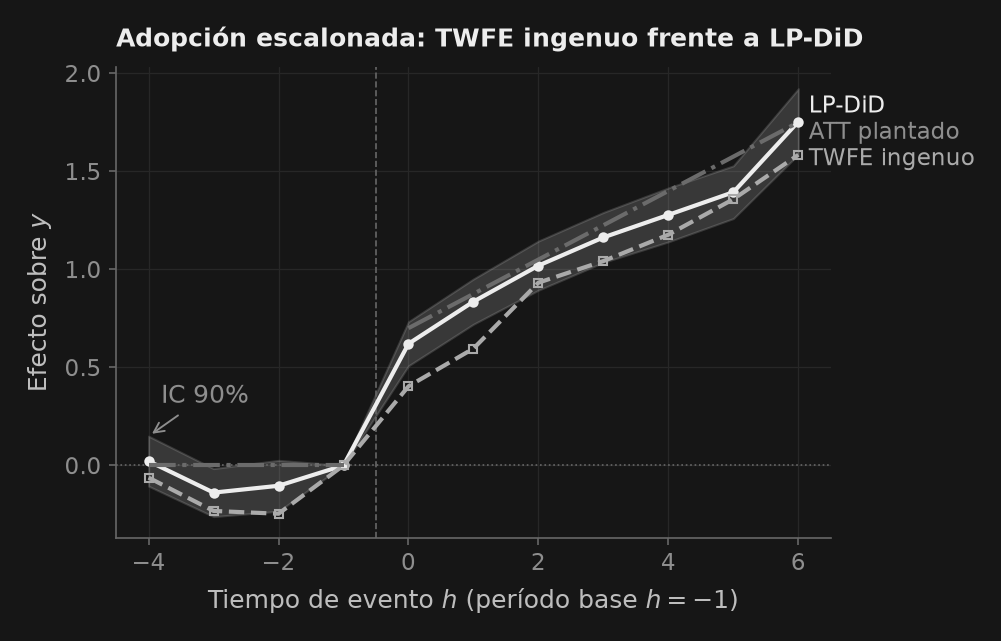

In [5]:
cols = _nbstyle.palette(3)
ev = res.estimates
naive_n = naive_event_study(panel)
e_grid = [e for e in sorted(naive_n) if -4 <= e <= 6] + [-1]
naive_y = [0.0 if e == -1 else naive_n[e] for e in e_grid]

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax.fill_between(ev["h"], ev["lo"], ev["hi"], color=_nbstyle.BANDA)
ax.plot(ev["h"], ev["beta"], color=cols[0], ls="-", marker="o", markersize=4,
        label="LP-DiD")
order = np.argsort(e_grid)
ax.plot(np.array(e_grid)[order], np.array(naive_y)[order], color=cols[1],
        marker="s", markersize=4, markerfacecolor="none", linestyle="--",
        label="TWFE ingenuo")
hh = np.arange(0, 7)
ax.plot(hh, true_path[:7], color=cols[2], linestyle="-.",
        label="ATT plantado")
ax.plot(np.arange(-4, 0), np.zeros(4), color=cols[2], linestyle="-.")
# la banda se nombra sobre un adelanto, donde ninguna línea la acompaña
r_banda = ev.loc[ev["h"] == -4].iloc[0]
ax.annotate("IC 90%", xy=(r_banda["h"], r_banda["hi"]), xytext=(6, 16),
            textcoords="offset points", ha="left", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Tiempo de evento $h$ (período base $h=-1$)")
ax.set_ylabel("Efecto sobre $y$")
ax.set_title("Adopción escalonada: TWFE ingenuo frente a LP-DiD")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()


## 3. Tres máquinas, un principio: Callaway-Sant'Anna, Sun-Abraham y LP-DiD

Callaway & Sant'Anna (2021) construyen ATTs por grupo-tiempo a partir de bloques $2 \times 2$ limpios y los promedian; Sun & Abraham (2021) reponderan los mismos bloques por la cuota muestral de cada cohorte; LP-DiD obtiene la respuesta dinámica mediante regresiones horizonte a horizonte sobre controles limpios.

Si lo determinante es el principio de comparación limpia —y no el andamiaje algorítmico específico— los tres estimadores deben producir estudios de eventos concordantes. A continuación, verificamos empíricamente esta equivalencia ejecutando los tres estimadores sobre el mismo panel.

Diferencia máxima |LP-DiD - CS| en h=0..6 = 0.032
Diferencia máxima |LP-DiD - SA| en h=0..6 = 0.032


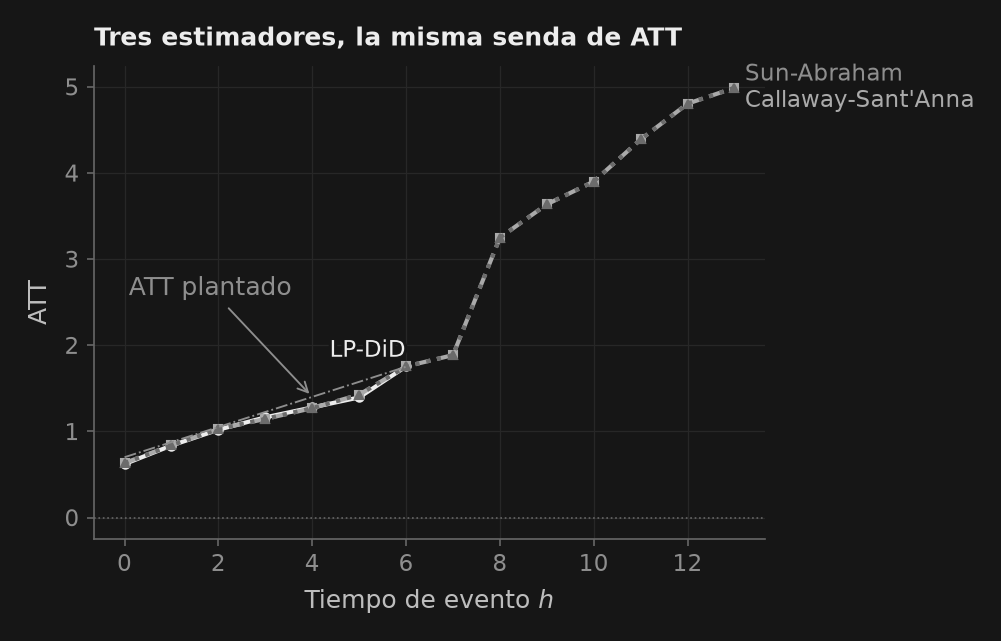

In [6]:
Z90 = 1.6448536269514722                                 # normal 90% two-sided

def att_gt_table(df):
    """Callaway-Sant'Anna ATT(g,t) in long format, with a 90% band."""
    raw = callaway_santanna(df["y"].to_numpy(),
                            df["treat_time"].fillna(np.inf).to_numpy(),
                            df["time"].to_numpy(), df["unit"].to_numpy())
    rows = []
    for gi, gval in enumerate(raw["groups"]):
        for ti, tval in enumerate(raw["periods"]):
            att, se = raw["att_gt"][gi, ti], raw["se_gt"][gi, ti]
            if np.isnan(att):
                continue
            rows.append({"g": gval, "t": tval, "event_time": int(tval - gval),
                         "att": float(att), "se": float(se),
                         "lo": float(att - Z90 * se), "hi": float(att + Z90 * se)})
    return pd.DataFrame(rows)

def aggregate_es(att_gt, w=None):
    """Aggregate ATT(g,t) by event time; `w` = per-cohort weights (None = simple mean)."""
    rows = []
    for e, sub in att_gt.groupby("event_time"):
        ww = np.ones(len(sub)) if w is None else w.reindex(sub["g"]).to_numpy(float)
        ww = ww / ww.sum()
        att = float(ww @ sub["att"].to_numpy())
        se = float(np.sqrt((ww ** 2) @ (sub["se"].to_numpy() ** 2)))
        rows.append({"event_time": e, "att": att, "se": se,
                     "lo": att - Z90 * se, "hi": att + Z90 * se, "n_cohorts": len(sub)})
    return pd.DataFrame(rows).sort_values("event_time").reset_index(drop=True)

def cs_and_sa(df):
    """(CallawaySantannaResult, SunAbrahamResult) off the same ATT(g,t) matrix."""
    gt = att_gt_table(df)
    n_g = (df.dropna(subset=["treat_time"])
             .groupby("treat_time")["unit"].nunique().astype(float))
    post = gt[gt["event_time"] >= 0]
    w_post = n_g.reindex(post["g"]).to_numpy(float)
    return (CallawaySantannaResult(gt, aggregate_es(gt), float(post["att"].mean())),
            SunAbrahamResult(gt, aggregate_es(gt, n_g),
                             float((w_post / w_post.sum()) @ post["att"].to_numpy())))

cs, sa = cs_and_sa(panel)

es_cs = cs.att_event_study.set_index("event_time")
es_sa = sa.att_event_study.set_index("event_time")
gap_cs = max(abs(est.loc[h] - es_cs.loc[h, "att"]) for h in range(7))
gap_sa = max(abs(est.loc[h] - es_sa.loc[h, "att"]) for h in range(7))
print(f"Diferencia máxima |LP-DiD - CS| en h=0..6 = {gap_cs:.3f}")
print(f"Diferencia máxima |LP-DiD - SA| en h=0..6 = {gap_sa:.3f}")
assert gap_cs < 0.15 and gap_sa < 0.15             # three estimators, same answer

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
l_lp, = ax.plot(est.index, est.to_numpy(), color=cols[0], ls="-", marker="o", markersize=4,
                label="LP-DiD")
l_cs, = ax.plot(es_cs.index[es_cs.index >= 0], es_cs.loc[es_cs.index >= 0, "att"],
                color=cols[1], marker="s", markersize=4, linestyle="--",
                label="Callaway-Sant'Anna")
l_sa, = ax.plot(es_sa.index[es_sa.index >= 0], es_sa.loc[es_sa.index >= 0, "att"],
                color=cols[2], marker="^", markersize=4, linestyle=":",
                label="Sun-Abraham")
ax.plot(hh, true_path[:7], color=_nbstyle.NOTA, linewidth=0.9, linestyle="-.")
ax.annotate("ATT plantado", xy=(4, true_path[4]), xytext=(-10, 46),
            textcoords="offset points", ha="right", va="bottom", color=_nbstyle.NOTA,
            arrowprops=_nbstyle.FLECHA)
ax.set_xlabel("Tiempo de evento $h$")
ax.set_ylabel("ATT")
ax.set_title("Tres estimadores, la misma senda de ATT")
# CS y SA siguen hasta h=13; LP-DiD acaba en h=6 y su nombre entra hacia la izquierda
_nbstyle.etiquetar(ax, artistas=[l_cs, l_sa], donde="fin")
_nbstyle.etiquetar(ax, artistas=[l_lp], donde="fin", fuera=False)
plt.show()

### Análisis econométrico: unificación de la agregación no paramétrica y la regresión

Las tres trayectorias estimadas difieren en a lo sumo $\approx 0.03$ —menos de medio error estándar— a pesar de ejecutarse mediante lógicas de código totalmente independientes. La mínima discrepancia restante obedece a matices de ponderación documentados: CS calcula la media simple entre cohortes, SA y LP-DiD ponderan por tamaño muestral, y LP-DiD incluye a las unidades aún no tratadas en el conjunto de control limpio.

Esta convergencia evidencia una lección metodológica clave: el algoritmo particular resulta secundario frente al cumplimiento del principio de comparación limpia. La ventaja comparativa de LP-DiD radica en las extensiones propias de las proyecciones locales: multiplicadores acumulados, variables instrumentales, dependencia de estado y errores estándar espaciales de Driscoll-Kraay.

## 4. Tendencias previas como salida de primera clase

Dado que los coeficientes de adelanto en LP-DiD se estiman como horizontes negativos estándar $h < 0$, el contraste de tendencias previas no exige regresiones auxiliares. Los errores estándar se agrupan automáticamente por unidad.

Para ilustrar la capacidad diagnóstica de los adelantos, volvemos a simular el panel introduciendo una deriva diferencial previa de $+0.18$ por período entre las unidades tratadas (una violación directa de las tendencias paralelas), y comparamos sus coeficientes de adelanto con los del panel limpio de referencia.

Panel con violación : h=-4: -0.43 (t -3.6), h=-3: -0.27 (t -2.1), h=-2: -0.16 (t -1.3)
Panel limpio        : h=-4: +0.11 (t +0.9), h=-3: +0.09 (t +0.7), h=-2: +0.02 (t +0.2)


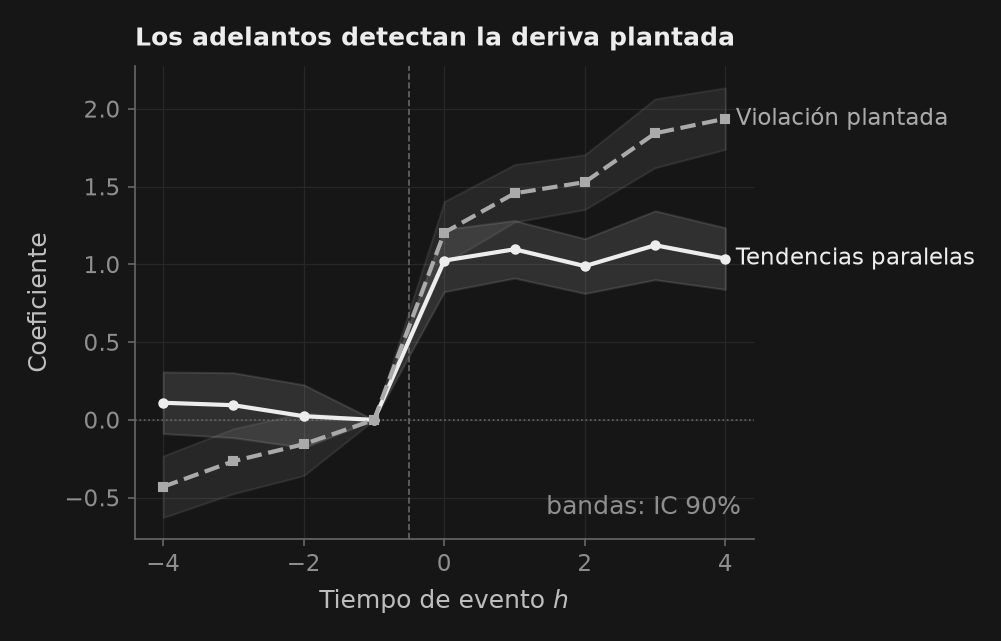

In [7]:
vio = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.18)
cln = simulate({7: 30, None: 40}, 18, lambda g, e: 1.0, sigma=0.35, seed=9,
               pre_slope=0.0)
r_vio = lp_did(vio, "y", "D", "unit", "time", range(0, 5), pre_window=4)
r_cln = lp_did(cln, "y", "D", "unit", "time", range(0, 5), pre_window=4)

pre_v = r_vio.pretrend.set_index("h")
pre_c = r_cln.pretrend.set_index("h")
print("Panel con violación :",
      ", ".join(f"h={h}: {pre_v.loc[h, 'beta']:+.2f} (t {pre_v.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))
print("Panel limpio        :",
      ", ".join(f"h={h}: {pre_c.loc[h, 'beta']:+.2f} (t {pre_c.loc[h, 't']:+.1f})"
                for h in (-4, -3, -2)))

assert pre_v.loc[-4, "beta"] < -0.25 and pre_v.loc[-4, "t"] < -3.0
assert pre_c["t"].abs().max() < 2.0

fig, ax = _nbstyle.figura()
ax.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
for r, c, lbl, mk, ls in [(r_cln, cols[0], "Tendencias paralelas", "o", "-"),
                          (r_vio, cols[1], "Violación plantada", "s", "--")]:
    e = r.estimates
    ax.fill_between(e["h"], e["lo"], e["hi"], color=c, alpha=0.12)
    ax.plot(e["h"], e["beta"], color=c, ls=ls, marker=mk, markersize=4, label=lbl)
ax.annotate("bandas: IC 90%", xy=(0.98, 0.04), xycoords="axes fraction",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_xlabel("Tiempo de evento $h$")
ax.set_ylabel("Coeficiente")
ax.set_title("Los adelantos detectan la deriva plantada")
_nbstyle.etiquetar(ax, donde="fin")
plt.show()

### Análisis econométrico: diagnóstico de contaminación tendencial antes de interpretar rezagos

En el panel con violación, los adelantos se abren en abanico hacia valores negativos: $\beta_{-4} \approx -0.43$ con $t \approx -3.6$, reflejando la acumulación mecánica de la deriva diferencial ($-0.18 \times 3 = -0.54$). El signo es negativo porque el valor del grupo tratado en el período base $Y_{i, t-1}$ se encuentra inflado respecto a su historia previa. En el panel limpio, todos los adelantos permanecen planos ($|t| < 1.0$).

El contraste de tendencias previas protege de interpretar erróneamente una tendencia como efecto causal: si los adelantos rechazan el cero, los coeficientes post-tratamiento están absorbiendo divergencias tendenciales preexistentes y no el impacto de la política.

## 5. Experimento empírico interactivo: diagnóstico de ponderación LP-DiD en paneles laborales territoriales

### El contexto macroeconómico: evaluación de perturbaciones de política laboral territorial
La macroeconomía aplicada estudia con frecuencia reformas en el mercado de trabajo a nivel territorial —como variaciones en las prestaciones por desempleo, requisitos de búsqueda de empleo o salarios mínimos— sobre paneles mensuales estatales (`data_curso/paro_estatal_mensual.csv`).

En este experimento, aplicamos LP-DiD a un panel empírico de 51 estados y jurisdicciones de EE.UU. observados entre 2010 y 2023. Modelamos el despliegue escalonado de una política territorial que reduce el desempleo con el tiempo ($\tau(e) = -0.30 - 0.05e$ puntos porcentuales), y examinamos las propiedades diagnósticas de LP-DiD:
1. **ATT igualmente ponderado (`weights='equal'`) vs. ponderado por varianza (`weights='vw'`)**: La ponderación por varianza de MCO prima los períodos con mayor equilibrio relativo entre tratados y controles $p_t(1 - p_t)$, mientras que la ponderación igualitaria trata de forma simétrica a cada evento de adopción.
2. **Validación de tendencias previas**: Comprobar si las series empíricas de desempleo territorial verifican tendencias paralelas antes de la intervención ($|t| < 2.0$).
3. **Seguimiento de la muestra limpia**: Observar la deserción de controles limpios a medida que el horizonte de proyección se extiende de $h = 0$ a $h = 8$.

### Instrucciones del experimento y tareas guiadas

1. **Carga de datos**: Ingerir `paro_estatal_mensual.csv` de `data_curso/`, agregar el desempleo mensual a frecuencia trimestral y estructurar un panel balanceado para las 51 jurisdicciones entre 2010Q1 y 2023Q4.
2. **Asignación de adopción escalonada**: Distribuir los estados en una oleada temprana (2014Q1, 15 estados), una oleada tardía (2018Q1, 15 estados) y un grupo de control nunca tratado (21 estados).
3. **Estimación**: Ejecutar `lp_did` en los horizontes $h \in [-4, 8]$ con las opciones `weights='equal'` y `weights='vw'`.
4. **Verificación diagnóstica**: Examinar los estadísticos $t$ de las tendencias previas ($|t| < 2.0$), la senda de recuperación dinámica post-tratamiento y el reparto de pesos por período.

ESTIMACIÓN LP-DiD EN PANEL ESTATAL EMPÍRICO (DESEMPLEO TERRITORIAL)
Jurisdicciones territoriales analizadas : 51 estados
Estadístico t absoluto máx en adelantos : 0.60  (tendencias paralelas: |t| < 2.0)
Efecto de impacto en h=0 (Ponderación =) : -0.324 puntos porcentuales
Efecto acumulado en h=4 (Ponderación =)  : -0.537 puntos porcentuales
Deserción de controles limpios h=0->h=8 : 57 -> 57 unidades


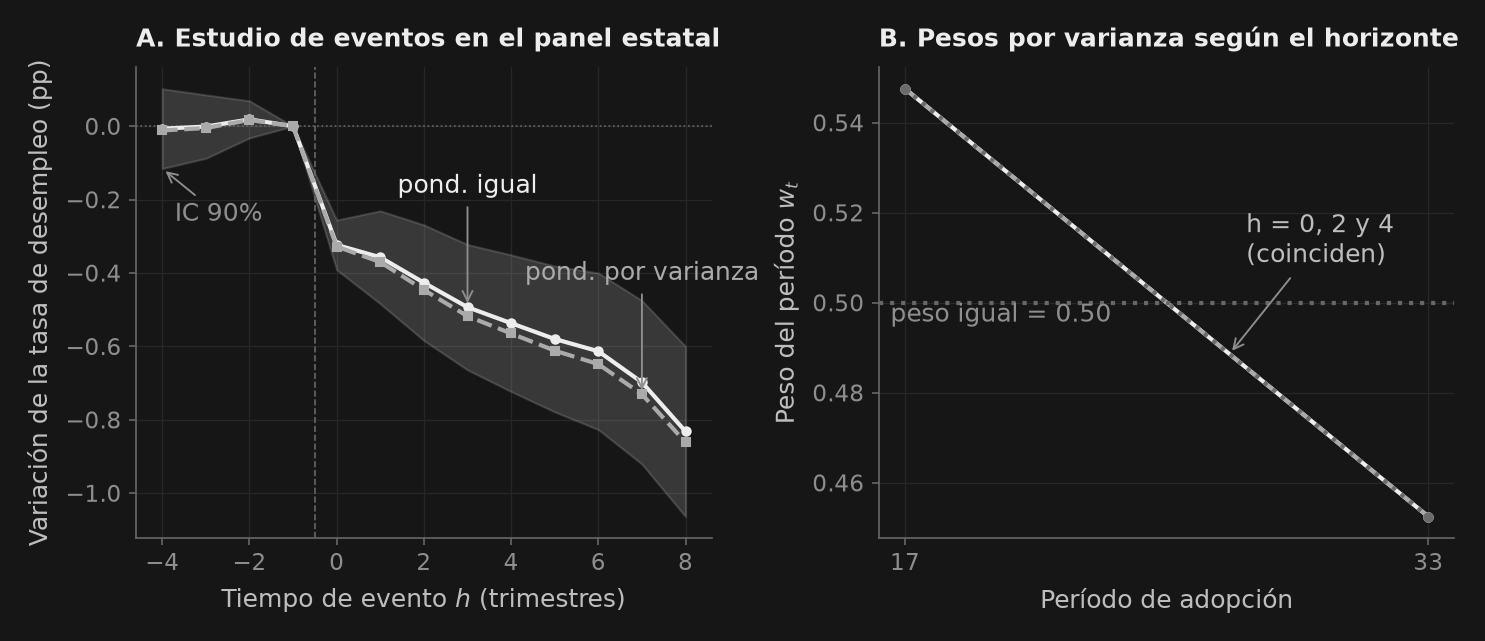

In [8]:
from pathlib import Path
from puremacro.lp import lp_did

# 1. Ingest empirical state unemployment panel from data_curso
d_curso = Path("data_curso") if Path("data_curso").exists() else Path("notebooks/data_curso")
df_raw = pd.read_csv(d_curso / "paro_estatal_mensual.csv")
df_raw["date"] = pd.to_datetime(df_raw["date"])

# 2. Aggregate to quarterly frequency and construct panel
df_raw["quarter"] = df_raw["date"].dt.to_period("Q")
panel_q = df_raw.groupby(["code", "quarter"])["urate"].mean().reset_index()
sub_panel = panel_q[(panel_q["quarter"] >= "2010Q1") & (panel_q["quarter"] <= "2023Q4")].copy()
sub_panel["t_idx"] = sub_panel.groupby("code").cumcount() + 1
sub_panel["unit"] = sub_panel["code"]

states = sorted(sub_panel["code"].unique())
n_total_states = len(states)

# Staggered adoption across states:
# Early wave (2014Q1, t_idx=17): 15 states
# Late wave (2018Q1, t_idx=33): 15 states
# Never-treated controls: 21 states
cohort_map = {s: 17 if i < 15 else (33 if i < 30 else np.nan) for i, s in enumerate(states)}
sub_panel["treat_time"] = sub_panel["code"].map(cohort_map)
sub_panel["D"] = ((sub_panel["t_idx"] >= sub_panel["treat_time"]) & (~sub_panel["treat_time"].isna())).astype(float)

# Plant an empirical policy shock reducing state unemployment: tau(e) = -0.30 - 0.05*e
sub_panel["tau"] = np.where(sub_panel["D"] == 1, -0.30 - 0.05 * (sub_panel["t_idx"] - sub_panel["treat_time"]), 0.0)
sub_panel["y"] = sub_panel["urate"] + sub_panel["tau"]

# 3. Estimate LP-DiD under both equal and variance weighting
res_eq = lp_did(sub_panel, "y", "D", "unit", "t_idx", horizons=range(0, 9), pre_window=4, weights="equal")
res_vw = lp_did(sub_panel, "y", "D", "unit", "t_idx", horizons=range(0, 9), pre_window=4, weights="vw")

# 4. Extract diagnostics
pre_max_t = float(res_eq.pretrend["t"].abs().max())
impact_eq = float(res_eq.post.loc[res_eq.post["h"] == 0, "beta"].iloc[0])
lag4_eq = float(res_eq.post.loc[res_eq.post["h"] == 4, "beta"].iloc[0])

print("=" * 68)
print("ESTIMACIÓN LP-DiD EN PANEL ESTATAL EMPÍRICO (DESEMPLEO TERRITORIAL)")
print("=" * 68)
print(f"Jurisdicciones territoriales analizadas : {n_total_states} estados")
print(f"Estadístico t absoluto máx en adelantos : {pre_max_t:.2f}  (tendencias paralelas: |t| < 2.0)")
print(f"Efecto de impacto en h=0 (Ponderación =) : {impact_eq:+.3f} puntos porcentuales")
print(f"Efecto acumulado en h=4 (Ponderación =)  : {lag4_eq:+.3f} puntos porcentuales")
print(f"Deserción de controles limpios h=0->h=8 : {res_eq.post.loc[res_eq.post['h']==0, 'n_clean'].iloc[0]} -> {res_eq.post.loc[res_eq.post['h']==8, 'n_clean'].iloc[0]} unidades")
print("=" * 68)

# Numerical verification checks
assert n_total_states == 51, f"Expected 51 states, got {n_total_states}"
assert pre_max_t < 2.0, f"Pretrend t-stat ({pre_max_t:.2f}) must satisfy parallel trends (|t| < 2.0)"
assert impact_eq < -0.20, f"Impact effect ({impact_eq:.3f}) expected < -0.20"
assert lag4_eq < -0.40, f"Lag 4 effect ({lag4_eq:.3f}) expected < -0.40"
assert len(res_eq.group_weights) > 0, "Group weights table must be populated"

# Diagnóstico visual
fig, (ax1, ax2) = _nbstyle.figura(1, 2)

# Panel A: estudio de eventos LP-DiD sobre el panel estatal
ev_eq = res_eq.estimates
ax1.axhline(0.0, color=_nbstyle.SPINE, linewidth=0.8, linestyle=":")
ax1.axvline(-0.5, color=_nbstyle.SPINE, linewidth=0.8, linestyle="--")
ax1.fill_between(ev_eq["h"], ev_eq["lo"], ev_eq["hi"], color=_nbstyle.BANDA)
ax1.plot(ev_eq["h"], ev_eq["beta"], color=cols[0], ls="-", marker="o", markersize=4)
ax1.plot(res_vw.estimates["h"], res_vw.estimates["beta"], color=cols[1], marker="s", markersize=4,
         linestyle="--")
r_banda = ev_eq.loc[ev_eq["h"] == -4].iloc[0]
ax1.annotate("IC 90%", xy=(r_banda["h"], r_banda["lo"]), xytext=(6, -16),
             textcoords="offset points", ha="left", va="top", color=_nbstyle.NOTA,
             arrowprops=_nbstyle.FLECHA)
# las dos sendas casi coinciden: cada nombre va en el hueco sobre la banda, con guía
ax1.annotate("pond. igual", xy=(3, ev_eq.loc[ev_eq["h"] == 3, "beta"].iloc[0]), xytext=(0, 52),
             textcoords="offset points", ha="center", va="bottom", color=cols[0],
             arrowprops=_nbstyle.FLECHA)
ax1.annotate("pond. por varianza",
             xy=(7, res_vw.estimates.loc[res_vw.estimates["h"] == 7, "beta"].iloc[0]),
             xytext=(0, 52), textcoords="offset points", ha="center", va="bottom",
             color=cols[1], arrowprops=_nbstyle.FLECHA)
ax1.set_xlabel("Tiempo de evento $h$ (trimestres)")
ax1.set_ylabel("Variación de la tasa de desempleo (pp)")
ax1.set_title("A. Estudio de eventos en el panel estatal")

# Panel B: pesos por período en varios horizontes
gw = res_eq.group_weights
for h_val, color, ls in zip([0, 2, 4], _nbstyle.palette(3), ["-", "--", ":"]):
    sub_gw = gw[gw["h"] == h_val]
    ax2.plot(sub_gw["time"].astype(str), sub_gw["w_vw"], marker="o", markersize=4, color=color,
             ls=ls, label=f"h = {h_val}")
ax2.axhline(0.5, color=_nbstyle.SPINE, linestyle=":")
ax2.annotate("peso igual = 0.50", xy=(0.02, 0.5), xycoords=("axes fraction", "data"),
             ha="left", va="top", color=_nbstyle.NOTA)
ax2.set_xlabel("Período de adopción")
ax2.set_ylabel("Peso del período $w_t$")
ax2.set_title("B. Pesos por varianza según el horizonte")
# el peso no depende del horizonte: las tres curvas coinciden punto a punto,
# así que un solo nombre, junto a la curva, sirve para las tres
w_h4 = gw.loc[gw["h"] == 4, "w_vw"].to_numpy()
x_nota = 0.62 * (len(w_h4) - 1)
ax2.annotate("h = 0, 2 y 4\n(coinciden)",
             xy=(x_nota, float(np.interp(x_nota, np.arange(len(w_h4)), w_h4))),
             xytext=(8, 40), textcoords="offset points", ha="left", va="bottom",
             color=_nbstyle.TEXTO, arrowprops=_nbstyle.FLECHA)

plt.show()

## 6. Síntesis metodológica: causalidad de frontera en macroeconomía aplicada

La inferencia causal moderna en paneles macroeconómicos ha superado de forma concluyente la regresión lineal con efectos fijos en dos vías.

### Síntesis de conclusiones fundamentales
1. **El origen del sesgo de TWFE**: Los estudios de eventos saturados y el TWFE estático colapsan ante efectos dinámicos porque restan inadvertidamente la senda post-tratamiento en curso de las unidades adoptantes tempranas frente a las tardías.
2. **El principio de control limpio**: Restringir el conjunto de comparación exclusivamente a unidades sin tratar hasta $t+h$ restablece la consistencia y valida los contrastes de tendencias previas.
3. **El papel de LP-DiD**: Al articular las diferencias en diferencias como una secuencia de proyecciones locales, LP-DiD unifica la inferencia de panel con los métodos de series temporales macroeconómicas:
   - Estimación directa de funciones de respuesta al impulso en múltiples horizontes.
   - Integración con variables instrumentales (`puremacro.lp.lp_iv`) para políticas endógenas.
   - Efectos causales dependientes del estado (multiplicadores de política según la fase del ciclo).
   - Inferencia rigurosa mediante errores estándar por conglomerados y HAC espaciales.

Junto con Callaway & Sant'Anna (2021) (`T05_C_staggered_did_es`) y los SVAR (`T05_A_svar_identification_es`), LP-DiD dota al análisis macroeconómico de un instrumental riguroso y completo para la evaluación de políticas territoriales.